# Deep CoxPH Training on AIDS Classification Dataset

This notebook demonstrates how to train a `DeepCoxPH` model from the `auton-survival` library using the `AIDS_Classification_50000.csv` dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from auton_survival.models.cph import DeepCoxPH
from auton_survival.metrics import survival_regression_metric

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

d:\Python\MLProjectsPW\survival_analysis_aids\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data

In [2]:
df = pd.read_csv('AIDS_Classification_50000.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (50000, 23)


,time,trt,age,wtkg,hemo,homo,drugs,karnof,oprior,z30,...,str2,strat,symptom,treat,offtrt,cd40,cd420,cd80,cd820,infected
0,1073,1,37,79.46339,0,1,0,100,0,1,...,1,2,0,1,0,322,469,882,754,1
1,324,0,33,73.02314,0,1,0,90,0,1,...,1,3,1,1,1,168,575,1035,1525,1
2,495,1,43,69.47793,0,1,0,100,0,1,...,1,1,0,0,0,377,333,1147,1088,1
3,1201,3,42,89.15934,0,1,0,100,1,1,...,1,3,0,0,0,238,324,775,1019,1
4,934,0,37,137.46581,0,1,0,100,0,0,...,0,3,0,0,1,500,443,1601,849,0


## 2. Preprocessing

We separate the data into features (`x`), time (`t`), and event (`e`). 
Numerical features are standardized, and categorical features are one-hot encoded.

In [3]:
# Define columns
time_col = 'time'
event_col = 'infected'

cat_feats = ['trt', 'hemo', 'homo', 'drugs', 'oprior', 'z30', 
             'race', 'gender', 'str2', 'strat', 'symptom', 
             'treat', 'offtrt']

num_feats = ['age', 'wtkg', 'karnof', 'preanti', 
             'cd40', 'cd420', 'cd80', 'cd820']

# Check for missing values
print("Missing values:\n", df.isnull().sum().sum())

Missing values:
 0


In [4]:
from sklearn.model_selection import train_test_split

# One-Hot Encoding for categorical features
x = pd.get_dummies(df.drop([time_col, event_col], axis = 1), 
                   columns=cat_feats, 
                   drop_first=True)

# Extract time and event
t = df[time_col]
e = df[event_col]

x_train, x_test, t_train, t_test, e_train, e_test = train_test_split(
    x, t, e, test_size=0.2, stratify=e, random_state=42
)

# Reset index to ensure consistency during evaluation
x_train, x_test = x_train.reset_index(drop=True), x_test.reset_index(drop=True)
t_train, t_test = t_train.reset_index(drop=True), t_test.reset_index(drop=True)
e_train, e_test = e_train.reset_index(drop=True), e_test.reset_index(drop=True)

# Standard Scaling for numerical features
scaler = StandardScaler()
x_train[num_feats] = scaler.fit_transform(x_train[num_feats])
x_test[num_feats] = scaler.transform(x_test[num_feats])

print(f"Train shape: {x_train.shape}")
print(f"Test shape: {x_test.shape}")

Train shape: (40000, 24)
Test shape: (10000, 24)


## 3. Train DeepCoxPH Model

We initialize a `DeepCoxPH` model with 2 hidden layers of 100 units each.

In [5]:
from sklearn.model_selection import ParameterGrid

# Define the hyperparameter grid
param_grid = {
    'layers': [[100], [100, 100], [64, 64]],
    'learning_rate': [1e-3, 5e-4, 1e-4 ],
    'optimizer': ['Adam', 'RMSProp', 'SGD']
}

# Pre-calculate outcomes for evaluation
outcomes_test = pd.DataFrame({'time': t_test, 'event': e_test})
outcomes_train = pd.DataFrame({'time': t_train, 'event': e_train})
eval_time = np.quantile(outcomes_train.time[outcomes_train.event==1], 0.5)

best_c_index = -1
best_params = None
best_model = None

print("Starting Hyperparameter Tuning...")
for params in ParameterGrid(param_grid):
    print(f"\nTesting params: {params}")
    # Initialize model with current layers
    curr_model = DeepCoxPH(layers=params['layers'])
    
    # Fit the model with current learning_rate and optimizer
    curr_model.fit(x_train, t_train, e_train, 
                  val_data=(x_test, t_test, e_test),
                  batch_size=64, 
                  iters=25, # Using 25 iterations for tuning speed
                  learning_rate=params['learning_rate'],
                  optimizer=params['optimizer'])
    
    # Predict risk and calculate C-index
    out_risk_curr = curr_model.predict_risk(x_test, t=eval_time)
    c_index = survival_regression_metric('ctd', outcomes_test, out_risk_curr, 
                                         times=eval_time, 
                                         outcomes_train=outcomes_train)
    
    curr_c_index = c_index[0]
    print(f"C-Index: {curr_c_index:.4f}")
    
    if curr_c_index > best_c_index:
        best_c_index = curr_c_index
        best_params = params
        best_model = curr_model

print("\nTuning Complete!")
print(f"Best Parameters Found: {best_params}")
print(f"Best C-Index: {best_c_index:.4f}")

# Assign the best model to 'model' for subsequent evaluation
model = best_model

Starting Hyperparameter Tuning...

Testing params: {'layers': [100], 'learning_rate': 0.001, 'optimizer': 'Adam'}


 60%|██████    | 15/25 [00:08<00:05,  1.86it/s]


C-Index: 0.3223

Testing params: {'layers': [100], 'learning_rate': 0.001, 'optimizer': 'RMSProp'}


 60%|██████    | 15/25 [00:07<00:04,  2.03it/s]


C-Index: 0.3223

Testing params: {'layers': [100], 'learning_rate': 0.001, 'optimizer': 'SGD'}


...

C-Index: 0.3196

Testing params: {'layers': [64, 64], 'learning_rate': 0.0001, 'optimizer': 'RMSProp'}


100%|██████████| 25/25 [00:13<00:00,  1.91it/s]


C-Index: 0.3195

Testing params: {'layers': [64, 64], 'learning_rate': 0.0001, 'optimizer': 'SGD'}


100%|██████████| 25/25 [00:12<00:00,  1.95it/s]


C-Index: 0.3205

Tuning Complete!
Best Parameters Found: {'layers': [100, 100], 'learning_rate': 0.001, 'optimizer': 'Adam'}
Best C-Index: 0.3237


Best Parameters Found: {'layers': [100, 100], 'learning_rate': 0.001, 'optimizer': 'Adam'}

## 4. Evaluation

We estimate the risk and calculate the C-index (Concordance Index) on the test set.

In [6]:
# Predict outcomes DataFrame
outcomes_test = pd.DataFrame({'time': t_test, 'event': e_test})
outcomes_train = pd.DataFrame({'time': t_train, 'event': e_train})

# Evaluate the model with C-index
eval_time = np.quantile(outcomes_train.time[outcomes_train.event==1], 0.5)
out_risk = model.predict_risk(x_test, t=eval_time) # returns numpy array

c_index = survival_regression_metric('ctd', outcomes_test, out_risk, 
                                     times=eval_time, 
                                     outcomes_train=outcomes_train)

print(f"Index Concordance (C-index) at median time {eval_time:.1f}: {c_index[0]:.4f}")

Index Concordance (C-index) at median time 994.0: 0.3237


### Survival Curves
We can also look at the predicted survival probabilities for specific subjects.

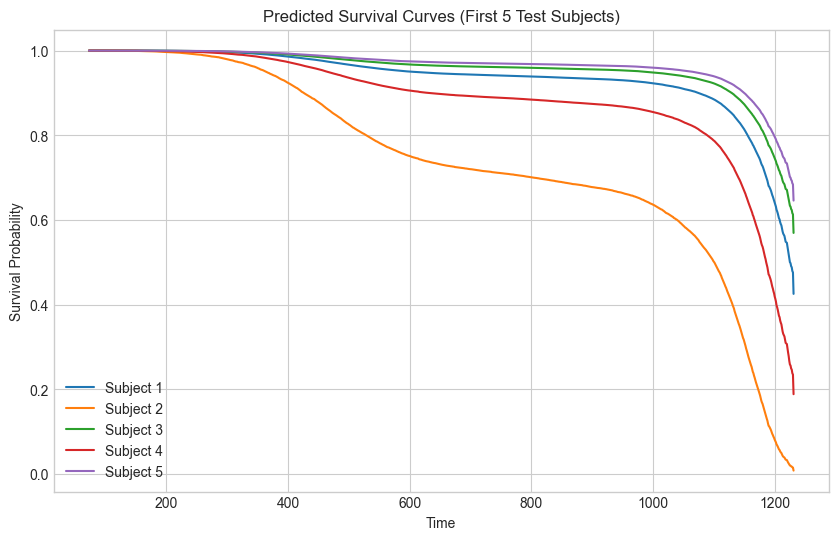

In [7]:
# Plot Predicted Survival Curves for a few samples
surv_probs = model.predict_survival(x_test.iloc[:5], t=None)
times = surv_probs.columns

plt.figure(figsize=(10, 6))
for i in range(len(surv_probs)):
    plt.plot(times, surv_probs.iloc[i], label=f"Subject {i+1}")

plt.ylabel("Survival Probability")
plt.xlabel("Time")
plt.title("Predicted Survival Curves (First 5 Test Subjects)")
plt.legend()
plt.show()

In [8]:
# Brier Score Evaluation at specific time horizons
times_brs = np.quantile(t_test[e_test==1], [0.25, 0.5, 0.75]).tolist()
out_risk_brs = model.predict_risk(x_test, t=times_brs)

brier_scores = survival_regression_metric('brs', outcomes_test, out_risk_brs, 
                                          times=times_brs, 
                                          outcomes_train=outcomes_train)

print("Brier Scores at specific time horizons:")
for t_horizon, score in zip(times_brs, brier_scores):
    print(f"Time {t_horizon:.1f}: {score:.4f}")

Brier Scores at specific time horizons:
Time 495.0: 0.7862
Time 978.0: 0.5913
Time 1127.0: 0.3953
